# Measured architecture

Read RSML file and run a simulation of the sap flux from an Arabidopsis de-topped root plunged in a hydroponic solution at a hydrostatic pressure of 0.4 Mpa when its  base is at the atmospheric pressure.

In [1]:
import openalea.rsml as rsml
from openalea.hydroroot import radius
from openalea.widgets.plantgl import PlantGL # notebook viewer 3D
from openalea.plantgl.algo.view import view # 2D view
from openalea.hydroroot.display import mtg_scene, property_scale_bar
from openalea.hydroroot.main import hydroroot_flow
from openalea.hydroroot.hydro_io import import_rsml_to_discrete_mtg

## RSML to MTG
1. Read the rsml file and convert it to a continuous MTG

In [2]:
g_c = rsml.rsml2mtg('plant-01.rsml')

2. Check the resolution (unit/pixel) and the unit

In [3]:
resolution = g_c.graph_properties()['metadata']['resolution'] # pixel to unit
unit = g_c.graph_properties()['metadata']['unit']
print(resolution, unit)

0.0001 m


3. convert the continuous MTG to discrete MTG

In [4]:
g = import_rsml_to_discrete_mtg(g_c, segment_length = 1.0e-4, resolution = resolution)

4. Set the root radii
   The radius setting follows the Arabidopsis model describeded in Boursiac et al. 2022. The root radius is set according to the radius of the primary root $r_{ref}$ and the order of the lateral as follows: $r_{lat} = \beta^{order} r_{ref}$. $\beta$ is the radius decreasing facteur between root orders.

In [5]:
g = radius.ordered_radius(g, 7.0e-5, 0.7) # primary root radius 7.0e-5 m, beta = 0.7
g = radius.compute_relative_position(g) # Compute the position of each segment relative to the axis bearing it

## Set hydraulic properties

In [14]:
k_radial_data=([0, 0.2],[30.0,30.0]) # radial conductivity profile: distance to tip (m) vs kr (10-9 m.s-1.MPa-1)
K_axial_data=([0, 0.2],[3.0e-7,4.0e-4]) # axial conductance profile: distance to tip (m) vs Kx (10-9 m4.s-1.MPa-1)

## Flux and equivalent conductance calculation

for a detopped root in a hydroponic medium at 0.4 MPa, its base at 0.1 MPa.

In [15]:
g, keq, jv = hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, 
                            axial_conductivity_data = K_axial_data, 
                            radial_conductivity_data = k_radial_data)

Print resuls

In [16]:
print('equivalent root conductance (10-9 m3/s/MPa): ',keq, 'sap flux (microL/s): ', jv)

equivalent root conductance (10-9 m3/s/MPa):  0.012060198401001499 sap flux (microL/s):  0.00361805952030045


## Plots

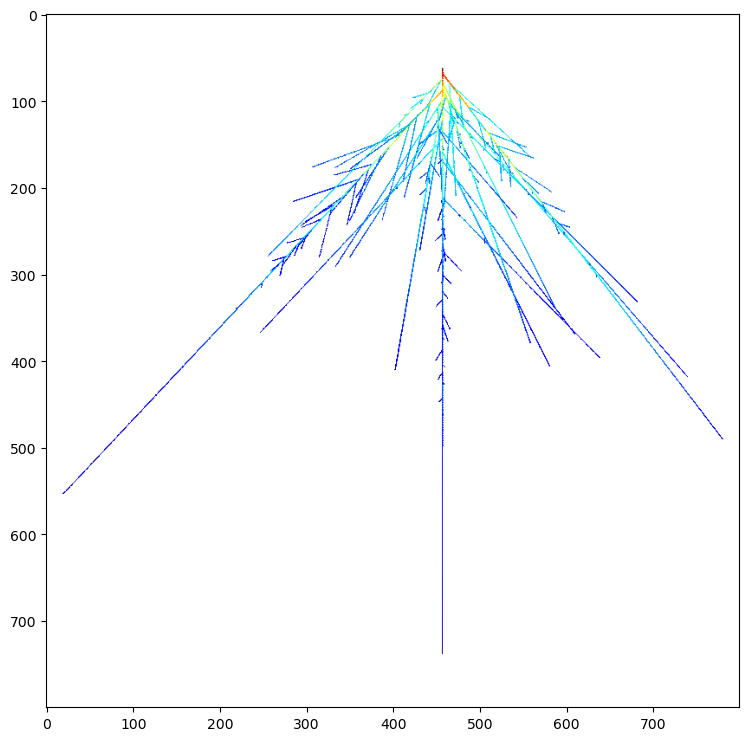

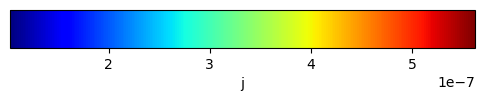

In [17]:
s = mtg_scene(g, prop_cmap = 'j') # create a scene from the mtg with the property j is the radial flux in ul/s
# PlantGL(s) # display the root into the plantgl oawidget
view(s) # view in 2D
property_scale_bar(g, 'j')

## Changing radial conductivity
You may change the radial conductivity and see the impact on the water uptake

sap flux (microL/s):  0.010609107156851389


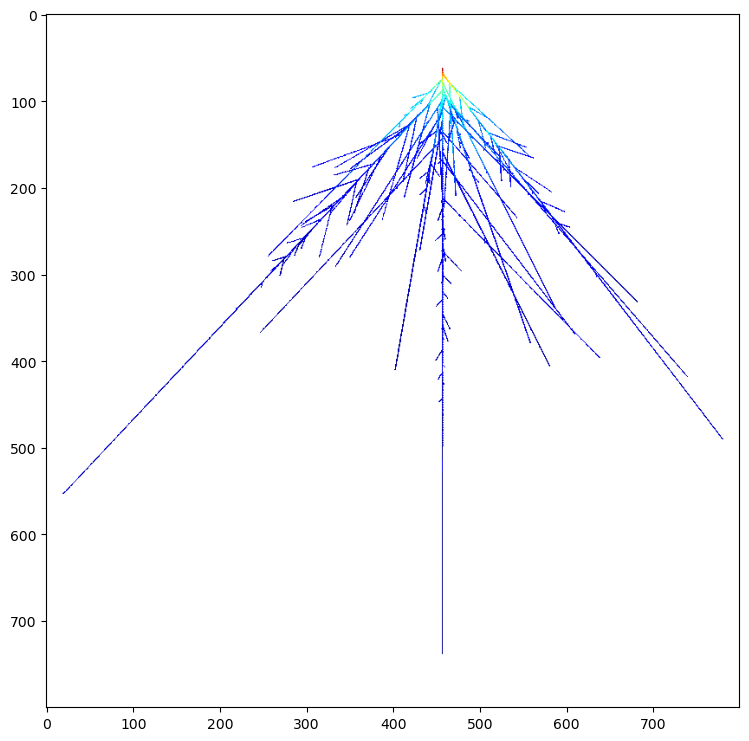

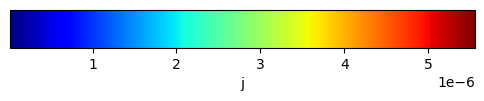

In [18]:
k_radial_data=([0, 0.2],[300.0,300.0])
g, keq, jv = hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, axial_conductivity_data = K_axial_data, radial_conductivity_data = k_radial_data)
print('sap flux (microL/s): ', jv)
s = mtg_scene(g, prop_cmap='j')
view(s) # to reduce notebook size we use here a 2D view but use PlantGL(s) to 3D
property_scale_bar(g, 'j')

## Changing axial conductance

sap flux (microL/s):  0.0019166890917623359


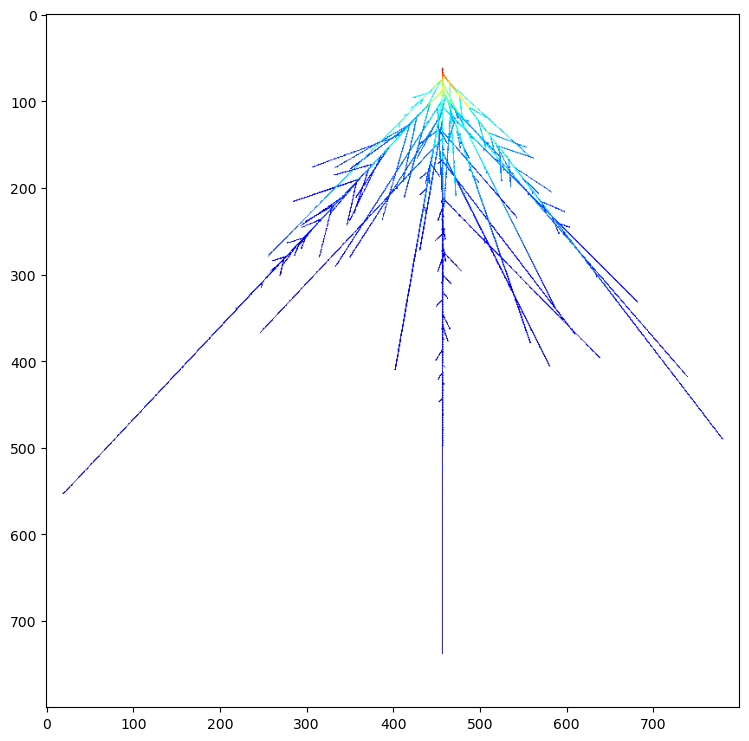

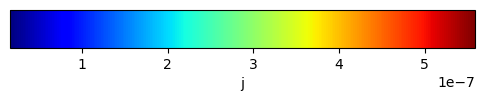

In [19]:
k_radial_data=([0, 0.2],[30.0,30.0])
K_axial_data=([0, 0.2],[3.0e-7,1.0e-4])
g, keq, jv = hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, axial_conductivity_data = K_axial_data, radial_conductivity_data = k_radial_data)
print('sap flux (microL/s): ', jv)
s = mtg_scene(g, prop_cmap='j')
view(s) # to reduce notebook size we use here a 2D view but use PlantGL(s) to 3D
property_scale_bar(g, 'j')

## PlantGl viewer

This is only working on **local machine**.

HydroRoot has also a function using the standalone Plantgl viewer allowing to specify the mtg property.

The following will open a standalone window with a 3D representation of the root. Uncomment the lines to run the cell locally.

In [12]:
# from openalea.hydroroot.display import plot
# %gui qt
# plot(g, prop_cmap='psi_in')